In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
from datasets import load_dataset
import re
import random
from tensorflow import keras

In [ ]:
ds = load_dataset("merve/poetry")

In [4]:
df = pd.DataFrame(ds["train"])

In [5]:
df["content"] = "<s> " + df["content"] + " </s>"

In [6]:
text = " ".join(df["content"].astype(str))
text = text.replace("\r\n", " ")
text = text.lower()
text = re.sub(r'([,;.!?])', r' \1 ', text) #stylistic choice
text = re.sub(r'\s+', ' ', text).strip()
tokens = text.split(" ")
unique = sorted(set(tokens))


In [7]:
from collections import Counter

In [8]:
class Tokenizer:
    def __init__(self):

        self.word2idx = {"<PAD>": 0, "<UNK>": 1, "<s>": 2, "</s>": 3}
        self.idx2word = {0: "<PAD>", 1: "<UNK>", 2: "<s>", 3: "</s>"}
        self.vocab_size = 4



    def fit(self, splitwords, max_vocab=5000):

      counts = Counter(splitwords)

      most_common = counts.most_common(max_vocab)

      for word, _ in most_common:

        if word not in self.word2idx:

            self.word2idx[word] = self.vocab_size
            self.idx2word[self.vocab_size] = word
            self.vocab_size += 1

    def encode(self, splitwords):
        return [self.word2idx.get(word, self.word2idx["<UNK>"]) for word in splitwords]

    def decode(self, indice):
        return " ".join([self.idx2word.get(idx, "<UNK>") for idx in indice])

In [9]:
tokenizer = Tokenizer()
tokenizer.fit(tokens, max_vocab = 5000)

encoded = tokenizer.encode(tokens)

print(tokenizer.vocab_size)
#print(encoded)
#print(tokenizer.decode(encoded))

5002


In [10]:
max_len = 200

In [11]:
sentences = []
current = []

for token in encoded:
    current.append(token)

    if token == 3:
        sentences.append(current)
        current = []

sentences = [s for s in sentences if len(s) <= max_len + 1]

random.Random(42).shuffle(sentences)

split_idx = int(len(sentences) * 0.8)

train_sentences = sentences[:split_idx]
val_sentences = sentences[split_idx:]


def build_dataset(sentences):

    inputs = []
    targets = []

    for s in sentences:

        inp = s[:-1]
        tar = s[1:]

        inp += [0] * (max_len - len(inp))
        tar += [0] * (max_len - len(tar))

        inputs.append(inp)
        targets.append(tar)

    return (
        np.array(inputs, dtype=np.int32),
        np.array(targets, dtype=np.int32)
    )


train_inputs, train_targets = build_dataset(train_sentences)
val_inputs, val_targets = build_dataset(val_sentences)

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_inputs, train_targets)
).shuffle(1000).batch(16)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_inputs, val_targets)
).batch(16)





In [ ]:
%pip install evaluate

In [13]:
import evaluate

In [14]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

In [15]:

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()

        pe = np.zeros((max_len, d_model))

        position = np.arange(max_len).reshape(-1, 1)
        dims = np.arange(0, d_model, 2).reshape(1, -1)
        div_term = np.power(10000, dims/d_model)

        pe[:, 0::2] = np.sin(position/div_term)
        pe[:, 1::2] = np.cos(position/div_term)

        #(1, max_len, d_model)
        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]



def causal_mask(seq_len):
    #upper triangle of ones, then invert it

    mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)

    #(1, 1, seq_len, seq_len)
    return mask[tf.newaxis, tf.newaxis, :, :]



def computation(Q, K, V, mask=None):
    d_k = tf.cast(tf.shape(Q)[-1], tf.float32)

    #(batch, heads, seq, seq)
    scores = tf.matmul(Q, K, transpose_b=True)/tf.math.sqrt(d_k)

    if mask is not None:
        scores = scores + (mask * -1e9)

    weights = tf.nn.softmax(scores, axis=-1)

    output = tf.matmul(weights, V)  #(batch, heads, seq, d_k)
    return output, weights



In [16]:

class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.d_k = d_model//num_heads

        self.W_Q = tf.keras.layers.Dense(d_model)
        self.W_K = tf.keras.layers.Dense(d_model)
        self.W_V = tf.keras.layers.Dense(d_model)
        self.W = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        #(batch, seq, d_model) → (batch, heads, seq, d_k)

        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.d_k))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def merge_heads(self, x, batch_size):
        #(batch, heads, seq, d_k) → (batch, seq, d_model)

        x = tf.transpose(x, perm=[0, 2, 1, 3])
        return tf.reshape(x, (batch_size, -1, self.num_heads * self.d_k))

    def call(self, x, mask=None):
        batch_size = tf.shape(x)[0]

        Q = self.split_heads(self.W_Q(x), batch_size)
        K = self.split_heads(self.W_K(x), batch_size)
        V = self.split_heads(self.W_V(x), batch_size)

        attn_out, weights = computation(Q, K, V, mask) #weights for heatmap visual later

        attn_out = self.merge_heads(attn_out, batch_size)
        return self.W(attn_out), weights



In [17]:

class DecoderBlock(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim):
        super().__init__()

        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ff1 = tf.keras.layers.Dense(ff_dim, activation='relu')
        self.ff2 = tf.keras.layers.Dense(d_model)
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()
        self.dropout1 = tf.keras.layers.Dropout(0.2)
        self.dropout2 = tf.keras.layers.Dropout(0.2)

    def call(self, x, mask=None, training=False):
        #causal + residual
        attn_out, _ = self.attention(x, mask=mask)
        attn_out = self.dropout1(attn_out, training=training)
        x = self.norm1(x + attn_out)

        #ff + residual
        ffn_out = self.ff2(self.ff1(x))
        ffn_out = self.dropout2(ffn_out, training=training)
        x = self.norm2(x + ffn_out)

        return x


In [18]:

class DecoderTransformer(tf.keras.Model):
    def __init__(self, vocab_size, d_model, num_heads, ff_dim, num_layers, max_len):
        super().__init__()

        self.token_emb = tf.keras.layers.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(max_len, d_model)
        self.dropout = tf.keras.layers.Dropout(0.3)
        self.blocks = [DecoderBlock(d_model, num_heads, ff_dim) for i in range(num_layers)]
        self.norm = tf.keras.layers.LayerNormalization()
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        mask = causal_mask(seq_len)

        x = self.token_emb(x)
        x = self.pos_enc(x)
        x = self.dropout(x, training=training)

        for block in self.blocks:
            x = block(x, mask=mask, training=training)

        x = self.norm(x)
        return self.fc(x)


In [31]:

d_model = 64
num_heads = 2
ff_dim = d_model * 2
num_layers= 2
max_len = 200


EPOCHS = 25
batchsize = 32

transformer = DecoderTransformer(
    vocab_size=tokenizer.vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_layers=num_layers,
    max_len=max_len
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, ignore_class=0)

In [ ]:
losstrack = []
acctrack  = []
ppl = []

accuracy_metric = evaluate.load("accuracy")


for epoch in range(1, EPOCHS + 1):



    # training
    train_loss, steps = 0, 0
    for x, y in train_ds:
        with tf.GradientTape() as tape:
            predictions = transformer(x, training=True)
            loss = loss_fn(y, predictions)
        grads = tape.gradient(loss, transformer.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, transformer.trainable_variables))
        train_loss += loss.numpy()
        steps += 1

    perplexity = np.exp(train_loss/steps)
    losstrack.append(train_loss)
    ppl.append(perplexity)

    # validation
    for x, y in val_ds:
        predictions = transformer(x, training=False)
        preds = tf.argmax(predictions, axis=-1).numpy().flatten()
        targets = y.numpy().flatten()
        mask = targets != 0
        accuracy_metric.add_batch(predictions=preds[mask], references=targets[mask])

    val_acc = accuracy_metric.compute()["accuracy"] * 100
    acctrack.append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS}  Loss: {train_loss/steps:.4f}  Val Acc: {val_acc:.2f}% PPL: {perplexity:.2f}")



In [35]:
import os


os.makedirs('./checkpoints/transformer/', exist_ok=True)
transformer.save_weights('./checkpoints/transformer/ckpt.weights.h5')

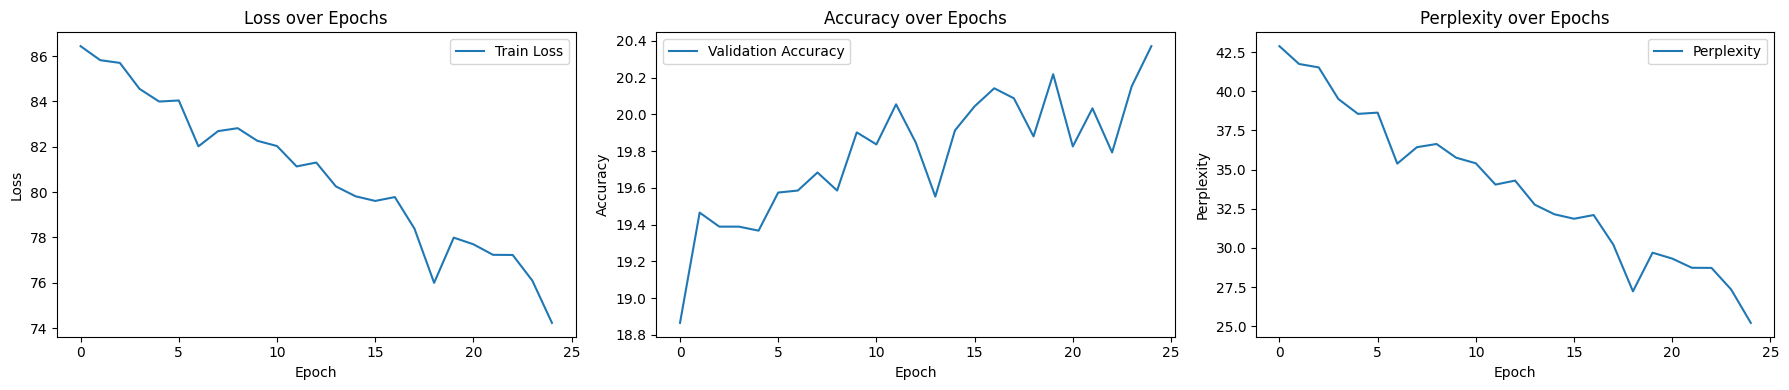

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 4))

plt.subplot(1, 3, 1)
plt.plot(losstrack, label='Train Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(acctrack, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(ppl, label='Perplexity')
plt.title('Perplexity over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.legend()

plt.tight_layout()
plt.show()

# DEMO

In [38]:
transformer.load_weights('./checkpoints/transformer/ckpt.weights.h5')

In [41]:
generated = tokenizer.encode(["i"])

for _ in range(max_len + 1):
    inputs = generated[-max_len:]
    paddingneeded = max(0, max_len - len(inputs))
    inputs = [0] * paddingneeded + inputs

    x = tf.constant([inputs], dtype=tf.int32)
    next_tok = tf.argmax(transformer(x, training=False)[0, -1]).numpy()

    generated.append(int(next_tok))

    if next_tok == 3:
        break

print(f"Generated Poem: '{tokenizer.decode(generated)}'")

Generated Poem: 'i seek some other where , and none . </s>'


In [ ]:
tf.config.list_physical_devices('GPU')

[]

In [ ]:
print(train_inputs.shape)
print(val_inputs.shape)

(354, 200)
(89, 200)


In [43]:
import seaborn as sns

# VISUAL REPRESENTATIONS

**Attention Heatmap**

Enter a phrase: The bird is on the flower in the sun and the leaves are falling


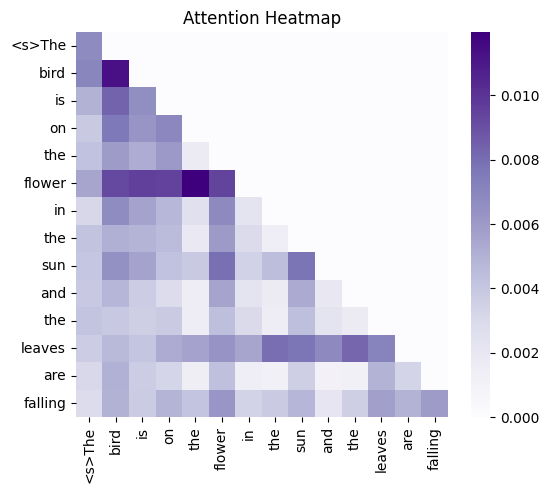

In [45]:
inp = str(input("Enter a phrase: "))
inp = "<s>" + inp
prompt = tokenizer.encode(inp.split())

x = tf.constant([[0] * (max_len - len(prompt)) + prompt], dtype=tf.int32)
seq_len = tf.shape(x)[1]
mask = causal_mask(seq_len)

emb = transformer.token_emb(x)
emb = transformer.pos_enc(emb)

_, weights = transformer.blocks[0].attention(emb, mask=mask) #from multiheadattention layer

tokens = inp.split()
w = weights[0, 0, -len(tokens):, -len(tokens):].numpy()


plt.figure(figsize=(6, 5))
sns.heatmap(w, xticklabels=tokens, yticklabels=tokens, cmap='Purples')
plt.title("Attention Heatmap")
plt.show()

**Token Probabilities**

Enter a phrase: I


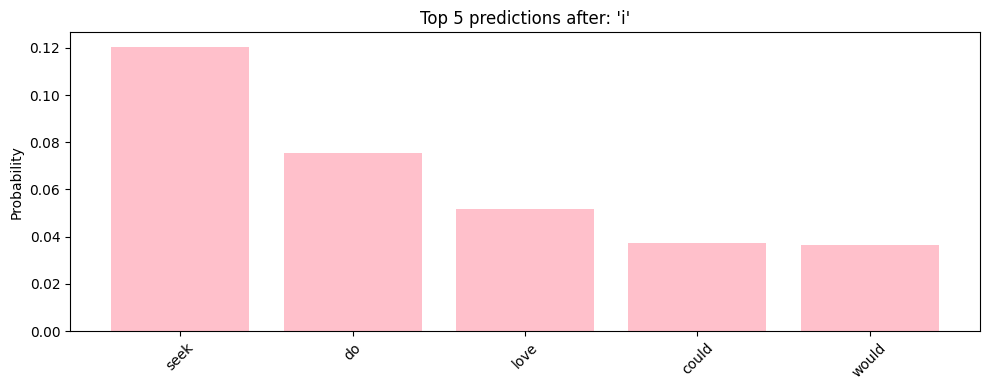

In [49]:
def probs(model, prompt, tokenizer, top_k=5):
    inputs  = [0] * (max_len - len(prompt)) + prompt
    x = tf.constant([inputs], dtype=tf.int32)
    logits = model(x, training=False)[0, -1]
    probs = tf.nn.softmax(logits).numpy()

    top_idx = probs.argsort()[-top_k:][::-1]
    top_words = [tokenizer.idx2word[i] for i in top_idx]
    top_probs = probs[top_idx]

    plt.figure(figsize=(10, 4))
    plt.bar(top_words, top_probs, color='pink')
    plt.title(f"Top {top_k} predictions after: '{tokenizer.decode(prompt)}'")
    plt.ylabel("Probability")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

inp = str(input("Enter a phrase: ")).lower()
prompt = tokenizer.encode(inp.split())

probs(transformer, prompt, tokenizer)